# USCRN paper workflow master

This notebook builds the full paper workflow from the cleaned long USCRN table.

## Outputs
- **Figure 1**: map of active-period data availability at 5 cm and 100 cm
- **Figure 2**: grouped boxplot of SM–VPD correlation across timescales, colored by depth, with station counts
- **Figure 3**: joint SM–VPD distributions by depth
- **Figure 4**: 3 × 3 synthetic mismatch figure, showing recovered coefficients, signed bias, and absolute error

## Active-period definition
A day is retained if:
- `tmax > 5`
- `vpd > 0.5`
- `No rain today or next day`

This notebook assumes you already created a cleaned long table and station metadata file.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
# ----------------------------
# User choices
# ----------------------------
RAIN_THRESH = 1.0          # mm
ACTIVE_TMAX_MIN = 5.0      # deg C
ACTIVE_VPD_MIN = 0.5       # kPa

def format_thresh(val):
    if val == 0:
        return "0"
    return str(val).replace(".", "")

TSTR = f"T{format_thresh(ACTIVE_TMAX_MIN)}"
VSTR = f"VPD{format_thresh(ACTIVE_VPD_MIN)}"
PSTR = f"P{format_thresh(RAIN_THRESH)}"

SUFFIX = f"{TSTR}_{VSTR}_{PSTR}"
print(SUFFIX)

T50_VPD05_P10


In [3]:
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 140,
})

DATA_DIR = Path("uscrn_processed")
OUT_DIR = Path("outputs/paper_workflow")
FIG_DIR = OUT_DIR / "figures"
TAB_DIR = OUT_DIR / "tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

LONG_TABLE = DATA_DIR / "uscrn_daily_long_2000_2026.parquet"   # edit if needed
STATION_META = DATA_DIR / "uscrn_station_metadata.parquet"      # edit if needed


## Load data

In [4]:
df = pd.read_parquet(LONG_TABLE)
station_meta = pd.read_parquet(STATION_META)

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["station_id", "date"]).reset_index(drop=True)
print(df.columns.tolist())
required_cols = [
    "station_id", "date", "lat", "lon", "tmax", "vpd",
    "sm_5", "sm_10", "sm_20", "sm_50", "sm_100"
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df.head()

['station_id', 'wban', 'date', 'year', 'month', 'doy', 'lat', 'lon', 'lat_round', 'lon_round', 'tmax', 'tmin', 'tavg', 'ppt', 'solarad', 'rh_max', 'rh_min', 'rh_avg', 'vpd', 'vpdmean', 'sm_5', 'sm_10', 'sm_20', 'sm_50', 'sm_100', 'st_5', 'st_10', 'st_20', 'st_50', 'st_100', 'source_file', 'source_stem', 'source_year_dir', 'CRX_VN', 'T_DAILY_MEAN', 'SUR_TEMP_DAILY_TYPE', 'SUR_TEMP_DAILY_MAX', 'SUR_TEMP_DAILY_MIN', 'SUR_TEMP_DAILY_AVG']


,station_id,wban,date,year,month,doy,lat,lon,lat_round,lon_round,...,st_100,source_file,source_stem,source_year_dir,CRX_VN,T_DAILY_MEAN,SUR_TEMP_DAILY_TYPE,SUR_TEMP_DAILY_MAX,SUR_TEMP_DAILY_MIN,SUR_TEMP_DAILY_AVG
0,0,3047,2003-05-21,2003,5,141,31.62,-102.81,31.62,-102.81,...,NaN,CRND0103-2003-TX_Monahans_6_ENE.txt,CRND0103-2003-TX_Monahans_6_ENE,2003,1.001,NaN,U,NaN,NaN,NaN
1,0,3047,2003-05-22,2003,5,142,31.62,-102.81,31.62,-102.81,...,NaN,CRND0103-2003-TX_Monahans_6_ENE.txt,CRND0103-2003-TX_Monahans_6_ENE,2003,1.001,20.0,R,NaN,NaN,22.8
2,0,3047,2003-05-23,2003,5,143,31.62,-102.81,31.62,-102.81,...,NaN,CRND0103-2003-TX_Monahans_6_ENE.txt,CRND0103-2003-TX_Monahans_6_ENE,2003,1.001,26.6,R,NaN,NaN,29.4
3,0,3047,2003-05-24,2003,5,144,31.62,-102.81,31.62,-102.81,...,NaN,CRND0103-2003-TX_Monahans_6_ENE.txt,CRND0103-2003-TX_Monahans_6_ENE,2003,1.001,28.5,R,NaN,NaN,27.5
4,0,3047,2003-05-25,2003,5,145,31.62,-102.81,31.62,-102.81,...,NaN,CRND0103-2003-TX_Monahans_6_ENE.txt,CRND0103-2003-TX_Monahans_6_ENE,2003,1.001,21.9,R,NaN,NaN,24.8


## Build active-period subset

This is the shared analysis dataset for Figures 1–4.


In [5]:
# mask_conus = (
#     df["lat"].between(24, 50) &
#     df["lon"].between(-125, -66)
# )

# mask_active = (
#     mask_conus &
#     (df["tmax"] > ACTIVE_TMAX_MIN) &
#     (df["vpd"] > ACTIVE_VPD_MIN)
# )

# df_active = df.loc[mask_active].copy()

# print("Rows in full table:", len(df))
# print("Rows in active table:", len(df_active))
# print("Stations in active table:", df_active["station_id"].nunique())

# ----------------------------
# Define CONUS mask if not already present
# ----------------------------
mask_conus = (
    df["lon"].between(-125, -66) &
    df["lat"].between(24, 50)
)

# ----------------------------
# Rain flags
# ----------------------------
df["is_rain"] = df["ppt"] > RAIN_THRESH

# previous day rain, by station
df["rain_prev_day"] = (
    df.groupby("station_id")["is_rain"]
      .shift(1)
      .fillna(False)
)

# ----------------------------
# Seasonal / meteorological filters
# ----------------------------
mask_may_sep = df["month"].between(5, 9)
mask_active = (
    (df["tmax"] > ACTIVE_TMAX_MIN) &
    (df["vpd"] > ACTIVE_VPD_MIN)
)

# ----------------------------
# Final clean mask
# May-Sep only
# exclude rain day
# exclude day after rain
# ----------------------------
mask_clean = (
    mask_conus &
    mask_may_sep &
    mask_active &
    (~df["is_rain"]) &
    (~df["rain_prev_day"])
)

df_active = df.loc[mask_clean].copy()

print(f"Original rows: {len(df):,}")
print(f"Filtered rows: {len(df_active):,}")
print(f"Retained fraction: {len(df_active)/len(df):.3f}")

print("\nStations retained:")
print(df_active['station_id'].nunique())

print("\nRows by month:")
print(df_active["month"].value_counts().sort_index())

print("\nRain day fraction in original data:")
print(df["is_rain"].mean())


Original rows: 1,245,951
Filtered rows: 159,375
Retained fraction: 0.128

Stations retained:
134

Rows by month:
month
5    28539
6    31924
7    33825
8    33774
9    31313
Name: count, dtype: int64

Rain day fraction in original data:
0.21245859588378677


/var/folders/ql/gv0k21w56llc1htbtgq4wzmm0000gn/T/ipykernel_14934/1656863863.py:35: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


## Helper functions

In [6]:
sm_cols = ["sm_5", "sm_10", "sm_20", "sm_50", "sm_100"]
depth_lookup = {"sm_5": 5, "sm_10": 10, "sm_20": 20, "sm_50": 50, "sm_100": 100}
depths = [5, 10, 20, 50, 100]

timescale_map = {
    "Daily": "1D",
    "Weekly": "1W",
    "Monthly": "1ME",
    "Seasonal": None,
}

MIN_PERIODS = {
    "Daily": 60,
    "Weekly": 20,
    "Monthly": 8,
    "Seasonal": 4,
}

depth_colors = {
    5: "#4C78A8",
    10: "#72B7B2",
    20: "#54A24B",
    50: "#ECA82C",
    100: "#B279A2",
}

def fit_no_intercept(y, x1, x2):
    x1 = np.asarray(x1).squeeze()
    x2 = np.asarray(x2).squeeze()
    y = np.asarray(y).squeeze()
    X = np.column_stack([x1, x2])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    yhat = X @ beta
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = np.nan if ss_tot == 0 else 1 - ss_res / ss_tot
    return beta[0], beta[1], r2


## Build summary tables used by the figures

In [7]:
# Figure 1 table: valid active-period days by depth
depth_counts = (
    df_active.groupby("station_id")
    .apply(
        lambda g: pd.Series({
            c: ((g[c].notna()) & (g["vpd"].notna())).sum()
            for c in sm_cols
        }),
        include_groups=False,
    )
    .reset_index()
    .merge(station_meta[["station_id", "lat", "lon"]].drop_duplicates(), on="station_id", how="left")
)

depth_counts.to_parquet(TAB_DIR / "station_depth_valid_counts_active.parquet", index=False)

depth_counts.head()


,station_id,sm_5,sm_10,sm_20,sm_50,sm_100,lat,lon
0,0,1957,1943,1978,1942,2000,31.62,-102.81
1,1,1826,1826,1826,1826,1826,34.36,-106.89
2,2,1610,1558,1610,1450,1610,33.96,-102.77
3,3,1473,1473,1473,1473,1473,36.60,-101.59
4,4,1685,1685,1685,1685,1684,38.54,-107.69


In [8]:
# Figure 2 table: station × depth × timescale correlations
results = []

for station_id, sub in df_active.groupby("station_id"):
    sub = sub.sort_values("date").set_index("date")

    for sm_col in sm_cols:
        depth_cm = depth_lookup[sm_col]
        dat0 = sub[[sm_col, "vpd"]].dropna().copy()

        if len(dat0) >= MIN_PERIODS["Daily"]:
            r_daily = dat0[sm_col].corr(dat0["vpd"])
            results.append({
                "station_id": station_id,
                "depth_cm": depth_cm,
                "timescale": "Daily",
                "n_periods": len(dat0),
                "r": r_daily,
            })

        for label, freq in timescale_map.items():
            if label == "Daily":
                continue

            if label == "Seasonal":
                # one May-Sep mean per year
                agg = dat0.groupby(dat0.index.year).mean().dropna()
            else:
                agg = dat0.resample(freq).mean().dropna()

            if len(agg) < MIN_PERIODS[label]:
                continue

            r = agg[sm_col].corr(agg["vpd"])
            results.append({
                "station_id": station_id,
                "depth_cm": depth_cm,
                "timescale": label,
                "n_periods": len(agg),
                "r": r,
            })

corr_by_scale = pd.DataFrame(results)
corr_by_scale.to_parquet(TAB_DIR / "corr_by_station_depth_timescale.parquet", index=False)

corr_by_scale.head()

,station_id,depth_cm,timescale,n_periods,r
0,0,5,Daily,1957,-0.108052
1,0,5,Weekly,358,-0.179964
2,0,5,Monthly,80,-0.050098
3,0,5,Seasonal,16,0.342053
4,0,10,Daily,1943,-0.140814


In [9]:
# Representativeness table: station × depth × timescale correlations with SM_5cm
results_sm5 = []

ref_col = "sm_5"

for station_id, sub in df_active.groupby("station_id"):
    sub = sub.sort_values("date").set_index("date")

    for sm_col in sm_cols:
        if sm_col == ref_col:
            continue

        depth_cm = depth_lookup[sm_col]
        dat0 = sub[[ref_col, sm_col]].dropna().copy()

        if len(dat0) >= MIN_PERIODS["Daily"]:
            r_daily = dat0[ref_col].corr(dat0[sm_col])
            results_sm5.append({
                "station_id": station_id,
                "depth_cm": depth_cm,
                "timescale": "Daily",
                "n_periods": len(dat0),
                "r": r_daily,
            })

        for label, freq in timescale_map.items():
            if label == "Daily":
                continue

            if label == "Seasonal":
                agg = dat0.groupby(dat0.index.year).mean().dropna()
            else:
                agg = dat0.resample(freq).mean().dropna()

            if len(agg) < MIN_PERIODS[label]:
                continue

            r = agg.iloc[:, 0].corr(agg.iloc[:, 1])

            results_sm5.append({
                "station_id": station_id,
                "depth_cm": depth_cm,
                "timescale": label,
                "n_periods": len(agg),
                "r": r,
            })

corr_sm5_by_scale = pd.DataFrame(results_sm5)
corr_sm5_by_scale.to_parquet(
    TAB_DIR / "corr_sm5_by_station_depth_timescale.parquet",
    index=False
)

corr_sm5_by_scale.head()

,station_id,depth_cm,timescale,n_periods,r
0,0,10,Daily,1900,0.716658
1,0,10,Weekly,355,0.734417
2,0,10,Monthly,80,0.693624
3,0,10,Seasonal,16,0.722661
4,0,20,Daily,1942,0.642134


In [10]:
# Figure 3 source table: long format for joint distributions
long_sm = df_active.melt(
    id_vars=["station_id", "date", "lat", "lon", "vpd"],
    value_vars=sm_cols,
    var_name="sm_depth_var",
    value_name="soil_moisture"
)
long_sm["depth_cm"] = long_sm["sm_depth_var"].map(depth_lookup)
long_sm = long_sm.dropna(subset=["soil_moisture", "vpd"]).copy()

long_sm.to_parquet(TAB_DIR / "joint_distribution_source.parquet", index=False)

long_sm.head()


,station_id,date,lat,lon,vpd,sm_depth_var,soil_moisture,depth_cm
0,0,2010-05-01,31.62,-102.81,0.857175,sm_5,0.011,5
1,0,2010-05-02,31.62,-102.81,1.335014,sm_5,0.010,5
2,0,2010-05-03,31.62,-102.81,1.445805,sm_5,0.007,5
3,0,2010-05-04,31.62,-102.81,1.987112,sm_5,0.005,5
4,0,2010-05-05,31.62,-102.81,2.278157,sm_5,0.004,5


In [11]:
# Figure 4 table: synthetic mismatch experiment using standardized predictors
TRUE_COEFF_VPD = 1.0
TRUE_COEFF_SM = 1.0
MIN_DAYS_SYNTHETIC = 500

depth_lookup_rev = {5: "sm_5", 10: "sm_10", 20: "sm_20", 50: "sm_50", 100: "sm_100"}

results_syn = []

for station_id, sub in df_active.groupby("station_id"):
    sub = sub.sort_values("date").copy()

    for true_depth in depths:
        true_sm_col = depth_lookup_rev[true_depth]

        for measured_depth in depths:
            measured_sm_col = depth_lookup_rev[measured_depth]

            cols = ["vpd", true_sm_col]
            if measured_sm_col != true_sm_col:
                cols.append(measured_sm_col)

            dat = sub[cols].dropna()

            if len(dat) < MIN_DAYS_SYNTHETIC:
                continue

            vpd = dat["vpd"].to_numpy()
            sm_true = dat[true_sm_col].to_numpy()
            sm_measured = dat[measured_sm_col].to_numpy()
            
            # standardize using the same sample used in the fit
            vpd_std = np.std(vpd)
            sm_true_std = np.std(sm_true)
            sm_measured_std = np.std(sm_measured)
            
            # skip pathological cases with no variance
            if (vpd_std == 0) or (sm_true_std == 0) or (sm_measured_std == 0):
                continue
            
            vpd_z = (vpd - np.mean(vpd)) / vpd_std
            sm_true_z = (sm_true - np.mean(sm_true)) / sm_true_std
            sm_measured_z = (sm_measured - np.mean(sm_measured)) / sm_measured_std
            
            y = (
                TRUE_COEFF_VPD * vpd_z
                + TRUE_COEFF_SM * sm_true_z
            )
            
            beta_vpd, beta_sm, r2 = fit_no_intercept(
                y,
                vpd_z,
                sm_measured_z
            )

            results_syn.append({
                "station_id": station_id,
                "true_depth_cm": true_depth,
                "measured_depth_cm": measured_depth,
                "n_days": len(dat),
                "beta_vpd": beta_vpd,
                "beta_sm": beta_sm,
                "r2": r2,
                "beta_vpd_bias": beta_vpd - TRUE_COEFF_VPD,
                "beta_sm_bias": beta_sm - TRUE_COEFF_SM,
                "beta_vpd_abs_error": abs(beta_vpd - TRUE_COEFF_VPD),
                "beta_sm_abs_error": abs(beta_sm - TRUE_COEFF_SM),
                "r2_loss": 1 - r2,
                "total_abs_error": abs(beta_vpd - TRUE_COEFF_VPD) + abs(beta_sm - TRUE_COEFF_SM),
            })

synthetic_station = pd.DataFrame(results_syn)
synthetic_summary = (
    synthetic_station.groupby(["true_depth_cm", "measured_depth_cm"])[
        ["beta_vpd", "beta_sm", "r2",
         "beta_vpd_bias", "beta_sm_bias",
         "beta_vpd_abs_error", "beta_sm_abs_error",
         "r2_loss", "total_abs_error"]
    ]
    .median()
    .reset_index()
)

synthetic_station.to_parquet(TAB_DIR / "synthetic_mismatch_station_level.parquet", index=False)
synthetic_summary.to_parquet(TAB_DIR / "synthetic_mismatch_summary.parquet", index=False)

synthetic_summary.head()


,true_depth_cm,measured_depth_cm,beta_vpd,beta_sm,r2,beta_vpd_bias,beta_sm_bias,beta_vpd_abs_error,beta_sm_abs_error,r2_loss,total_abs_error
0,5,5,1.000000,1.000000,1.000000,2.220446e-16,0.000000,6.106227e-16,7.771561e-16,0.000000,1.443290e-15
1,5,10,0.957751,0.914429,0.896994,-4.224899e-02,-0.085571,4.224899e-02,8.557146e-02,0.103006,1.305189e-01
2,5,20,0.898430,0.807686,0.791589,-1.015700e-01,-0.192314,1.015700e-01,1.923143e-01,0.208411,2.811975e-01
3,5,50,0.817466,0.593924,0.574445,-1.825344e-01,-0.406076,1.825344e-01,4.060762e-01,0.425555,5.892958e-01
4,5,100,0.759959,0.429964,0.494039,-2.400413e-01,-0.570036,2.400413e-01,5.700356e-01,0.505961,8.029646e-01


# Figure S1. Active-period data availability map (>500 valid days)


5 cm: n = 108
100 cm: n = 80


/var/folders/ql/gv0k21w56llc1htbtgq4wzmm0000gn/T/ipykernel_14934/3298132632.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


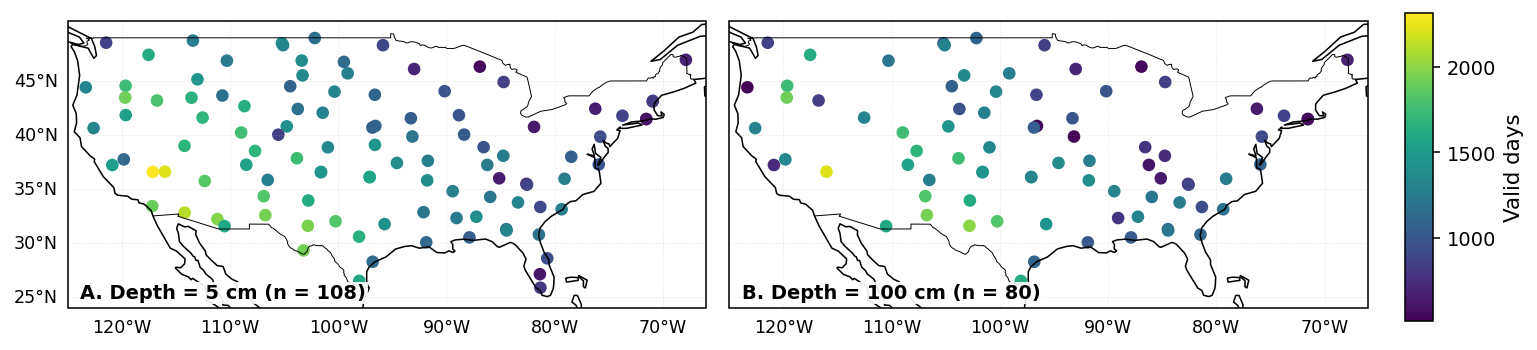

In [12]:
cols = ["sm_5", "sm_100"]
titles = ["5 cm", "100 cm"]
min_points_map = 500

plot_data = depth_counts.loc[(depth_counts[cols] > min_points_map).any(axis=1)].copy()
vmin = plot_data[cols].where(plot_data[cols] > min_points_map).min().min()
vmax = plot_data[cols].max().max()

fig, axes = plt.subplots(
    1, 2, figsize=(10, 4),
    subplot_kw={'projection': ccrs.PlateCarree()},
    sharex=True, sharey=True
)

for i, (ax, col, title) in enumerate(zip(axes, cols, titles)):
    subset = depth_counts[depth_counts[col] > min_points_map]

    n_sites = len(subset)
    print(f"{title}: n = {n_sites}")  # <-- prints for caption

    sc = ax.scatter(
        subset["lon"],
        subset["lat"],
        c=subset[col],
        s=30,
        vmin=vmin,
        vmax=vmax,
        transform=ccrs.PlateCarree()
    )

    # Map features
    ax.coastlines(resolution='110m', linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    ax.set_extent([-125, -66, 24, 47])

    # Gridlines
    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.3,
        alpha=0.3,
        linestyle="--"
    )

    gl.top_labels = False
    gl.right_labels = False
    if i == 1:
        gl.left_labels = False

    gl.xlocator = plt.FixedLocator(np.arange(-120, -60, 10))
    gl.ylocator = plt.FixedLocator(np.arange(25, 50, 5))

    gl.xlabel_style = {'size': 9}
    gl.ylabel_style = {'size': 9}

    # ---- PANEL LABEL WITH DEPTH + N ----
    panel_label = f"{chr(65 + i)}. Depth = {title} (n = {n_sites})"

    ax.text(
        0.02, 0.02,
        panel_label,
        transform=ax.transAxes,
        fontsize=10,
        fontweight='bold',
        va='bottom',
        bbox=dict(facecolor="white", alpha=0.9, edgecolor="none", pad=1)
    )

axes[0].set_ylabel("Latitude")

# Colorbar
fig.subplots_adjust(right=0.82)

cbar_ax = fig.add_axes([1.01, 0.22, 0.02, 0.55])
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label("Valid days")

fig.tight_layout()
fig.savefig(FIG_DIR / f"FigureS1_data_availability_{SUFFIX}.png", dpi=300, bbox_inches="tight")
plt.show()

# Figure 1. Representiveness boxplot across timescales


=== FIGURE 1: SM5 REPRESENTATIVENESS ===

--- Daily ---
Depth  10 cm: median r = 0.93, std = 0.12, n = 126
Depth  20 cm: median r = 0.85, std = 0.20, n = 101
Depth  50 cm: median r = 0.65, std = 0.26, n = 100
Depth 100 cm: median r = 0.48, std = 0.26, n = 98

--- Weekly ---
Depth  10 cm: median r = 0.93, std = 0.11, n = 127
Depth  20 cm: median r = 0.86, std = 0.20, n = 102
Depth  50 cm: median r = 0.67, std = 0.27, n = 101
Depth 100 cm: median r = 0.51, std = 0.26, n = 96

--- Monthly ---
Depth  10 cm: median r = 0.94, std = 0.14, n = 123
Depth  20 cm: median r = 0.89, std = 0.22, n = 99
Depth  50 cm: median r = 0.75, std = 0.30, n = 98
Depth 100 cm: median r = 0.54, std = 0.28, n = 91

--- Seasonal ---
Depth  10 cm: median r = 0.90, std = 0.21, n = 114
Depth  20 cm: median r = 0.87, std = 0.29, n = 90
Depth  50 cm: median r = 0.73, std = 0.36, n = 88
Depth 100 cm: median r = 0.60, std = 0.40, n = 88



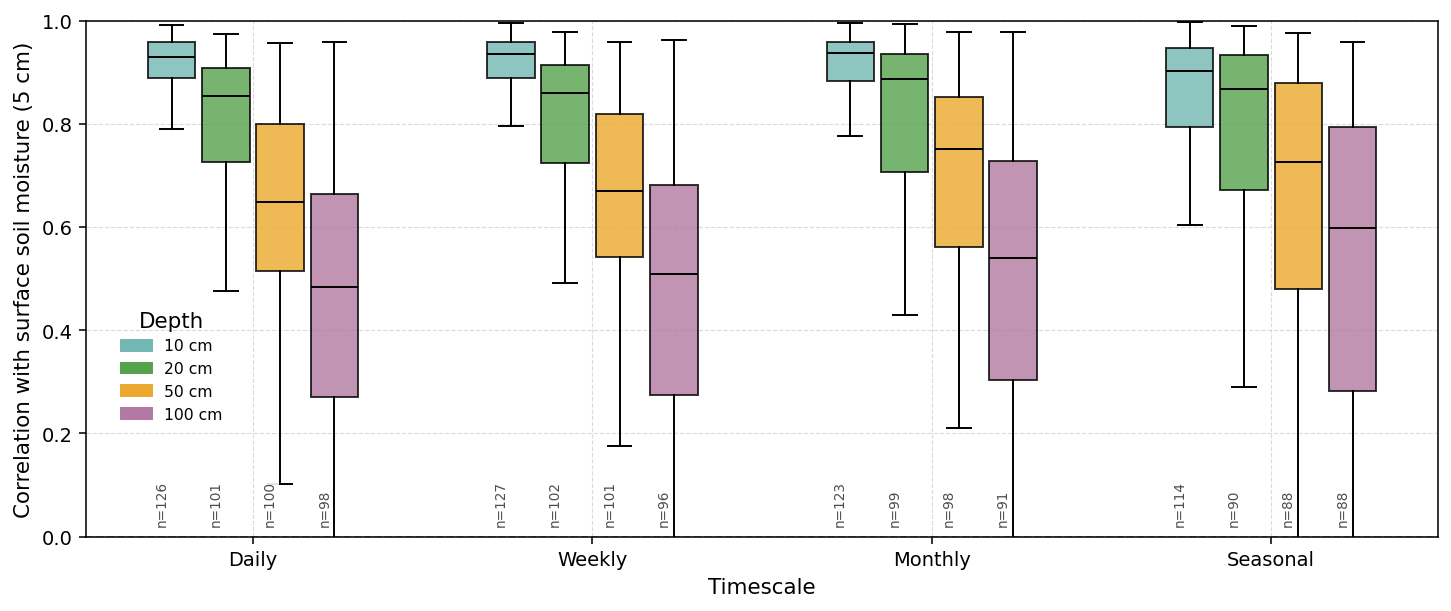

In [13]:
# =====================================================
# FIGURE 1: REPRESENTATIVENESS OF 5 CM SOIL MOISTURE
# Correlation between SM_5cm and deeper soil moisture
# across timescales
# =====================================================

# assumes you already created:
# corr_sm5_by_scale
# with columns: station_id, depth_cm, timescale, n_periods, r

# --- SUMMARY / COUNTS ---
counts_sm5 = (
    corr_sm5_by_scale
    .groupby(["timescale", "depth_cm"])["station_id"]
    .nunique()
    .reset_index(name="n_stations")
)

timescales = ["Daily", "Weekly", "Monthly", "Seasonal"]

# depths to include in representativeness figure
depths_rep = [10, 20, 50, 100]


# =====================================================
# PRINT SUMMARY STATS (Fig. 1)
# =====================================================

summary_sm5 = (
    corr_sm5_by_scale
    .groupby(["timescale", "depth_cm"])["r"]
    .agg(["median", "mean", "std", "count"])
    .reset_index()
)

print("\n=== FIGURE 1: SM5 REPRESENTATIVENESS ===\n")

for ts in timescales:
    print(f"--- {ts} ---")
    sub = summary_sm5[summary_sm5["timescale"] == ts]

    for depth in depths_rep:
        row = sub[sub["depth_cm"] == depth]

        if len(row) == 0:
            continue

        med = row["median"].values[0]
        std = row["std"].values[0]
        n = int(row["count"].values[0])

        print(f"Depth {depth:>3} cm: median r = {med:.2f}, std = {std:.2f}, n = {n}")

    print("")

# use same centers/offset logic as Fig. 2
fig, ax = plt.subplots(1, 1, figsize=(10.5, 4.5))

group_centers = np.arange(len(timescales))
offsets = np.linspace(-0.24, 0.24, len(depths_rep))
width = 0.14

for offset, depth in zip(offsets, depths_rep):
    data = []
    positions = []

    for i, ts in enumerate(timescales):
        vals = corr_sm5_by_scale.loc[
            (corr_sm5_by_scale["timescale"] == ts) &
            (corr_sm5_by_scale["depth_cm"] == depth),
            "r"
        ].dropna().values

        data.append(vals)
        positions.append(group_centers[i] + offset)

    bp = ax.boxplot(
        data,
        positions=positions,
        widths=width,
        patch_artist=True,
        manage_ticks=False,
        showfliers=False,
    )

    for patch in bp["boxes"]:
        patch.set_facecolor(depth_colors[depth])
        patch.set_alpha(0.8)

    for element in ["whiskers", "caps", "medians"]:
        for artist in bp[element]:
            artist.set_color("black")

# --- labels / axes ---
ax.set_xticks(group_centers)
ax.set_xticklabels(timescales)
ax.set_ylabel(r"Correlation with surface soil moisture (5 cm)")
ax.set_xlabel("Timescale")
ax.set_ylim(0, 1)
ax.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.4)

# --- n labels ---
for i, ts in enumerate(timescales):
    for offset, depth in zip(offsets, depths_rep):
        n = counts_sm5.loc[
            (counts_sm5["timescale"] == ts) &
            (counts_sm5["depth_cm"] == depth),
            "n_stations"
        ]
        if len(n) == 0:
            continue

        ax.text(
            group_centers[i] + offset - 0.03,
            0.02,
            f"n={int(n.values[0])}",
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=90,
            color="0.3",
            bbox=dict(facecolor="white", alpha=0.9, edgecolor="none", pad=1)
        )

# --- legend ---
handles = [mpatches.Patch(color=depth_colors[d], label=f"{d} cm") for d in depths_rep]
ax.legend(
    handles=handles,
    title="Depth",
    loc="lower left",
    bbox_to_anchor=(0.015, 0.195),
    frameon=False,
    fontsize=8
    
)

# --- grid styling ---
ax.grid(
    True,
    which="major",
    linestyle="--",
    linewidth=0.6,
    color="0.8",
    alpha=0.7
)
ax.set_axisbelow(True)

# --- finalize ---
fig.tight_layout()
fig.savefig(
    FIG_DIR / f"Figure1_representativeness_sm5_by_timescale_{SUFFIX}.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Figure 2. Grouped boxplot across timescales


Median coupling statistics by timescale and depth:
timescale  depth_cm  median_r  median_r2  n_stations
    Daily         5 -0.327908   0.107524         126
    Daily        10 -0.294717   0.086859         126
    Daily        20 -0.259728   0.067458         101
    Daily        50 -0.188656   0.037858         100
    Daily       100 -0.100444   0.014717          98
  Monthly         5 -0.460493   0.212054         123
  Monthly        10 -0.442638   0.195929         123
  Monthly        20 -0.362144   0.155503          99
  Monthly        50 -0.256271   0.080047          98
  Monthly       100 -0.125406   0.027804          91
 Seasonal         5 -0.485909   0.249455         114
 Seasonal        10 -0.465406   0.224655         114
 Seasonal        20 -0.483436   0.248390          90
 Seasonal        50 -0.404264   0.196508          88
 Seasonal       100 -0.287571   0.149163          88
   Weekly         5 -0.412851   0.170446         127
   Weekly        10 -0.361926   0.130991       

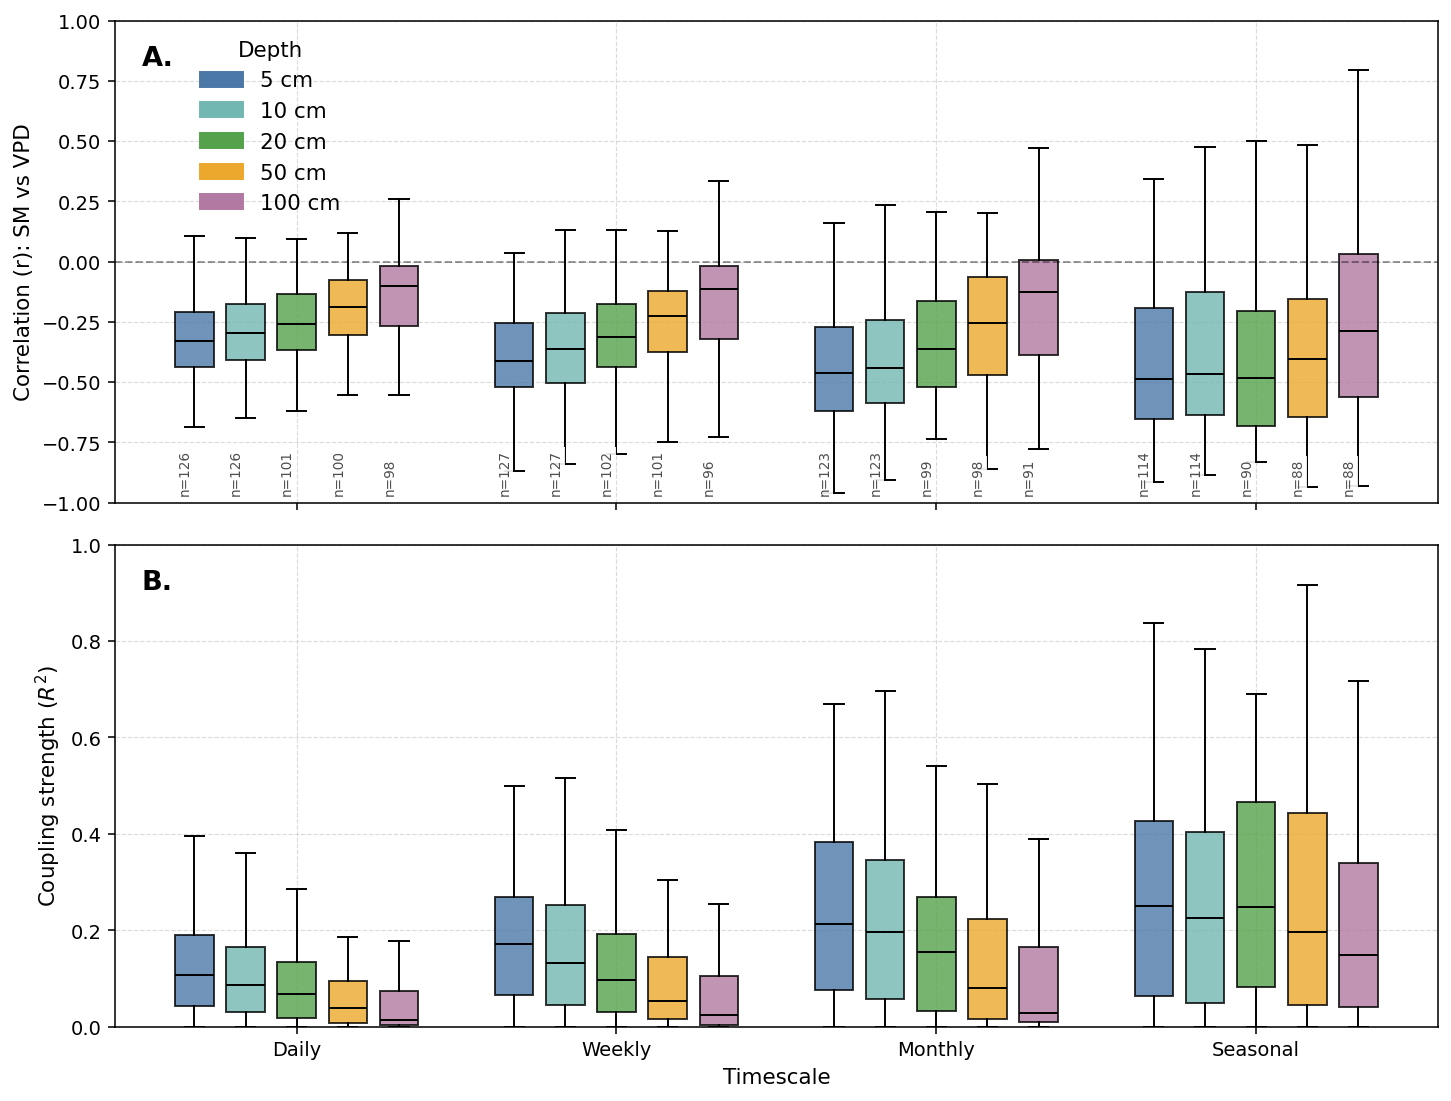

In [14]:
# --- PREP ---
corr_by_scale["r2"] = corr_by_scale["r"]**2


# --- SUMMARY NUMBERS TO REPORT ---
summary_stats = (
    corr_by_scale
    .groupby(["timescale", "depth_cm"])
    .agg(
        median_r=("r", "median"),
        median_r2=("r2", "median"),
        n_stations=("station_id", "nunique")
    )
    .reset_index()
)

print("\nMedian coupling statistics by timescale and depth:")
print(summary_stats.to_string(index=False))

# --- specific numbers for text (5 cm vs 100 cm, daily vs seasonal) ---
key_stats = summary_stats[
    summary_stats["depth_cm"].isin([5, 100]) &
    summary_stats["timescale"].isin(["Daily", "Seasonal"])
].copy()

print("\nKey text values (5 cm vs 100 cm; Daily vs Seasonal):")
print(key_stats.to_string(index=False))

# --- compare timescale effect vs depth effect using median R² ---
r2_5_daily = summary_stats.loc[
    (summary_stats["timescale"] == "Daily") & (summary_stats["depth_cm"] == 5),
    "median_r2"
].values[0]

r2_5_seasonal = summary_stats.loc[
    (summary_stats["timescale"] == "Seasonal") & (summary_stats["depth_cm"] == 5),
    "median_r2"
].values[0]

r2_100_seasonal = summary_stats.loc[
    (summary_stats["timescale"] == "Seasonal") & (summary_stats["depth_cm"] == 100),
    "median_r2"
].values[0]

timescale_effect = r2_5_seasonal - r2_5_daily
depth_effect = r2_5_seasonal - r2_100_seasonal

print("\nEffect size comparison using median R²:")
print(f"5 cm: Daily to Seasonal increase = {timescale_effect:.3f}")
print(f"Seasonal: 5 cm to 100 cm decrease = {depth_effect:.3f}")

counts = (
    corr_by_scale
    .groupby(["timescale", "depth_cm"])["station_id"]
    .nunique()
    .reset_index(name="n_stations")
)

timescales = ["Daily", "Weekly", "Monthly", "Seasonal"]

# --- FIGURE SETUP (STACKED) ---
fig, axes = plt.subplots(2, 1, figsize=(10.5, 8), sharex=True)

group_centers = np.arange(len(timescales))
offsets = np.linspace(-0.32, 0.32, len(depths))
width = 0.12

# =====================================================
# PANEL A: SIGNED CORRELATION (r)
# =====================================================
ax = axes[0]

for offset, depth in zip(offsets, depths):
    data = []
    positions = []

    for i, ts in enumerate(timescales):
        vals = corr_by_scale.loc[
            (corr_by_scale["timescale"] == ts) &
            (corr_by_scale["depth_cm"] == depth),
            "r"
        ].dropna().values

        data.append(vals)
        positions.append(group_centers[i] + offset)

    bp = ax.boxplot(
        data,
        positions=positions,
        widths=width,
        patch_artist=True,
        manage_ticks=False,
        showfliers=False,
    )

    for patch in bp["boxes"]:
        patch.set_facecolor(depth_colors[depth])
        patch.set_alpha(0.8)

    for element in ["whiskers", "caps", "medians"]:
        for artist in bp[element]:
            artist.set_color("black")

# Labels
ax.set_ylabel("Correlation (r): SM vs VPD")
ax.set_ylim(-1, 1)
ax.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.4)
# ax.set_title("A. Signed coupling")
ax.text(
    0.02, 0.95,
    "A.",
    transform=ax.transAxes,
    fontsize=14,
    fontweight='bold',
    ha='left',
    va='top',
    bbox=dict(facecolor="white", alpha=0.9, edgecolor="none", pad=1)
)



# --- n labels ONLY on panel A ---
for i, ts in enumerate(timescales):
    for offset, depth in zip(offsets, depths):
        n = counts.loc[
            (counts["timescale"] == ts) &
            (counts["depth_cm"] == depth),
            "n_stations"
        ]
        if len(n) == 0:
            continue

        ax.text(
            group_centers[i] + offset - 0.03,
            -0.97,
            f"n={int(n.values[0])}",
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=90,
            color="0.3",
            bbox=dict(facecolor="white", alpha=0.9, edgecolor="none", pad=1)
        )

# --- legend ONLY on panel A ---
handles = [mpatches.Patch(color=depth_colors[d], label=f"{d} cm") for d in depths]
ax.legend(
    handles=handles,
    title="Depth",
    loc="upper left",
    bbox_to_anchor=(0.05, 1),  # move right from default
    frameon=False
)

# =====================================================
# PANEL B: COUPLING STRENGTH (R²)
# =====================================================
ax = axes[1]

for offset, depth in zip(offsets, depths):
    data = []
    positions = []

    for i, ts in enumerate(timescales):
        vals = corr_by_scale.loc[
            (corr_by_scale["timescale"] == ts) &
            (corr_by_scale["depth_cm"] == depth),
            "r2"
        ].dropna().values

        data.append(vals)
        positions.append(group_centers[i] + offset)

    bp = ax.boxplot(
        data,
        positions=positions,
        widths=width,
        patch_artist=True,
        manage_ticks=False,
        showfliers=False,
    )

    for patch in bp["boxes"]:
        patch.set_facecolor(depth_colors[depth])
        patch.set_alpha(0.8)

    for element in ["whiskers", "caps", "medians"]:
        for artist in bp[element]:
            artist.set_color("black")

# Labels
ax.set_xticks(group_centers)
ax.set_xticklabels(timescales)
ax.set_ylabel(r"Coupling strength ($R^2$)")
ax.set_xlabel("Timescale")
ax.set_ylim(-0, 1)
# ax.set_title("B. Magnitude of coupling")

ax.text(
    0.02, 0.95,
    "B.",
    transform=ax.transAxes,
    fontsize=14,
    fontweight='bold',
    ha='left',
    va='top',
    bbox=dict(facecolor="white", alpha=0.9, edgecolor="none", pad=1)
)

for ax in axes:
    ax.grid(
        True,
        which="major",
        linestyle="--",
        linewidth=0.6,
        color="0.8",
        alpha=0.7
    )
    ax.set_axisbelow(True)
# =====================================================
# FINALIZE
# =====================================================
fig.tight_layout()
fig.savefig(FIG_DIR / f"Figure2_coupling_r_and_r2_stacked_{SUFFIX}.png", dpi=300, bbox_inches="tight")
plt.show()

# Figure 3. Joint SM–VPD distributions by depth

/var/folders/ql/gv0k21w56llc1htbtgq4wzmm0000gn/T/ipykernel_14934/980496931.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.14, 1, 1])


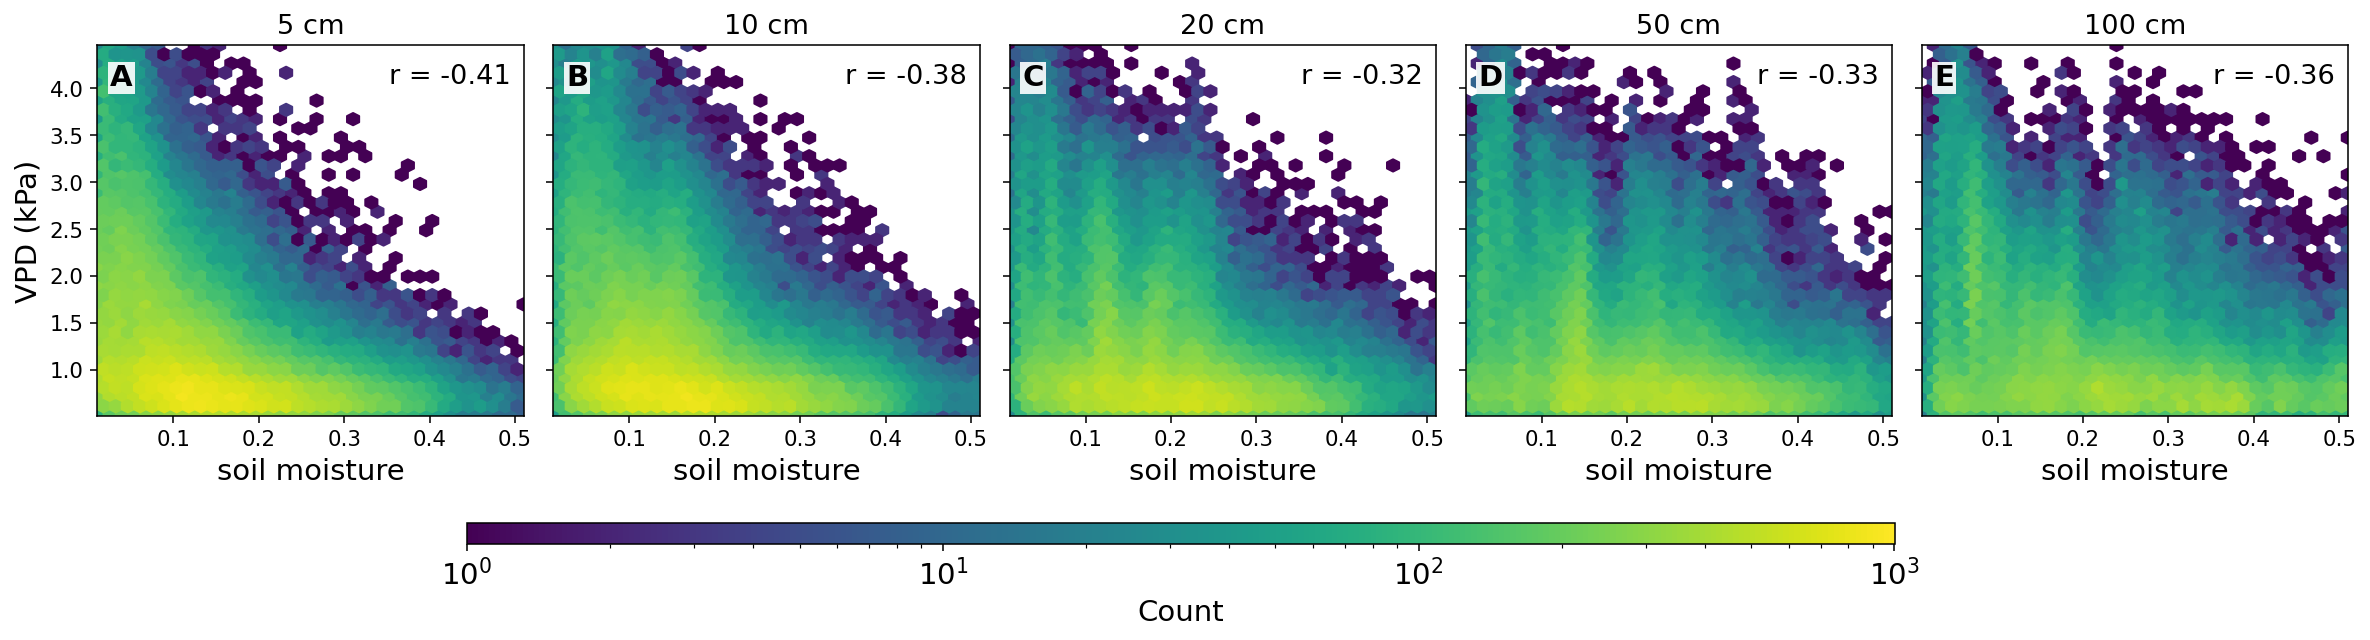

In [15]:
fig, axes = plt.subplots(
    1, len(depths),
    figsize=(3.4 * len(depths), 4.3),
    sharex=True,
    sharey=True
)

if len(depths) == 1:
    axes = [axes]

xlim = (
    np.nanpercentile(long_sm["soil_moisture"], 1),
    np.nanpercentile(long_sm["soil_moisture"], 99)
)
ylim = (
    np.nanpercentile(long_sm["vpd"], 1),
    np.nanpercentile(long_sm["vpd"], 99)
)

panel_labels = ["A", "B", "C", "D", "E"]

all_counts = []
for depth in depths:
    sub = long_sm[long_sm["depth_cm"] == depth]
    x = sub["soil_moisture"].to_numpy()
    y = sub["vpd"].to_numpy()
    mask = np.isfinite(x) & np.isfinite(y)
    H, _, _ = np.histogram2d(x[mask], y[mask], bins=35, range=[xlim, ylim])
    all_counts.append(H)

vmax = max(H.max() for H in all_counts)
norm = LogNorm(vmin=1, vmax=vmax)

for i, (ax, depth) in enumerate(zip(axes, depths)):
    sub = long_sm[long_sm["depth_cm"] == depth]

    h = ax.hexbin(
        sub["soil_moisture"],
        sub["vpd"],
        gridsize=35,
        mincnt=1,
        extent=(xlim[0], xlim[1], ylim[0], ylim[1]),
        norm=norm,
    )

    r = sub["soil_moisture"].corr(sub["vpd"])

    ax.set_title(f"{depth} cm", fontsize=14)
    ax.text(0.03, 0.95, panel_labels[i], transform=ax.transAxes,
            ha="left", va="top", fontsize=15, fontweight="bold",bbox=dict(facecolor="white", alpha=0.9, edgecolor="none", pad=1))
    ax.text(0.97, 0.95, f"r = {r:.2f}", transform=ax.transAxes,
            ha="right", va="top", fontsize=14,
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=1))

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.tick_params(labelsize=11)

    if i == 0:
        ax.set_ylabel("VPD (kPa)", fontsize=15)
    ax.set_xlabel("soil moisture", fontsize=15)

cbar_ax = fig.add_axes([0.2, 0.08, 0.6, 0.035])
cbar = fig.colorbar(h, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Count", fontsize=15)
cbar.ax.tick_params(labelsize=15)

# fig.suptitle("Figure 3. Joint SM–VPD distributions by depth", y=1.03, fontsize=16)
fig.tight_layout(rect=[0, 0.14, 1, 1])
fig.savefig(FIG_DIR / f"Figure3_joint_distributions_by_depth_{SUFFIX}.png", dpi=300, bbox_inches="tight")
plt.show()


# Figure 4. Synthetic depth mismatch (top row only)



--- KEY NUMBERS FROM SYNTHETIC EXPERIMENT ---

Model fit when depth is correct (diagonal R²):
  5 cm: R² = 1.00
  10 cm: R² = 1.00
  20 cm: R² = 1.00
  50 cm: R² = 1.00
  100 cm: R² = 1.00
  Mean diagonal R²: 1.00

Model fit under strong mismatch:
  True 5 cm vs far depth → R² = 0.49
  True 10 cm vs far depth → R² = 0.53
  True 20 cm vs far depth → R² = 0.63
  True 50 cm vs far depth → R² = 0.74
  True 100 cm vs far depth → R² = 0.55
  Mean mismatch R²: 0.59

Soil moisture coefficient bias (examples):
  True 100 cm, measured 5 cm → β_sm = 0.46
  True 5 cm, measured 100 cm → β_sm = 0.43

VPD coefficient compensation (examples):
  True 100 cm, measured 5 cm → β_vpd = 1.02
  True 5 cm, measured 100 cm → β_vpd = 0.76


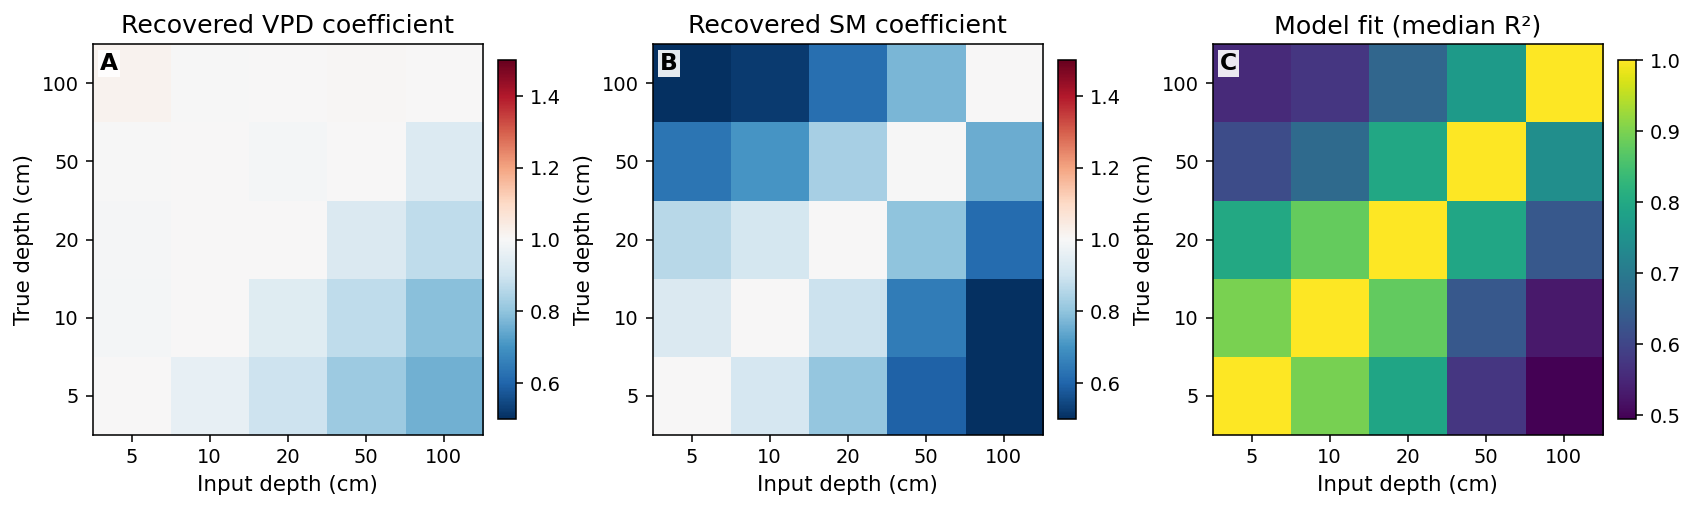

In [16]:
from matplotlib.colors import TwoSlopeNorm

# Pivot tables
pivot_vpd = synthetic_summary.pivot(index="true_depth_cm", columns="measured_depth_cm", values="beta_vpd")
pivot_sm  = synthetic_summary.pivot(index="true_depth_cm", columns="measured_depth_cm", values="beta_sm")
pivot_r2  = synthetic_summary.pivot(index="true_depth_cm", columns="measured_depth_cm", values="r2")

print("\n--- KEY NUMBERS FROM SYNTHETIC EXPERIMENT ---")

depths = pivot_r2.index.values

# 1. Perfect match (diagonal)
diag_r2 = [pivot_r2.loc[d, d] for d in depths]
print("\nModel fit when depth is correct (diagonal R²):")
for d, val in zip(depths, diag_r2):
    print(f"  {d} cm: R² = {val:.2f}")

print(f"  Mean diagonal R²: {np.mean(diag_r2):.2f}")

# 2. Worst mismatch (max distance)
max_mismatch_r2 = []
for d in depths:
    far_depth = depths[0] if d == depths[-1] else depths[-1]
    val = pivot_r2.loc[d, far_depth]
    max_mismatch_r2.append(val)

print("\nModel fit under strong mismatch:")
for d, val in zip(depths, max_mismatch_r2):
    print(f"  True {d} cm vs far depth → R² = {val:.2f}")

print(f"  Mean mismatch R²: {np.mean(max_mismatch_r2):.2f}")

# 3. SM coefficient bias (shallow vs deep mismatch)
print("\nSoil moisture coefficient bias (examples):")
print(f"  True 100 cm, measured 5 cm → β_sm = {pivot_sm.loc[100, 5]:.2f}")
print(f"  True 5 cm, measured 100 cm → β_sm = {pivot_sm.loc[5, 100]:.2f}")

# 4. VPD compensation
print("\nVPD coefficient compensation (examples):")
print(f"  True 100 cm, measured 5 cm → β_vpd = {pivot_vpd.loc[100, 5]:.2f}")
print(f"  True 5 cm, measured 100 cm → β_vpd = {pivot_vpd.loc[5, 100]:.2f}")

def plot_heatmap(ax, df_summary, value_col, title, panel_label, cmap=None):
    pivot = df_summary.pivot(index="true_depth_cm", columns="measured_depth_cm", values=value_col)
    
    if value_col in ["beta_vpd", "beta_sm"]:
        norm = TwoSlopeNorm(vmin=0.5, vcenter=1.0, vmax=1.5)
        im = ax.imshow(pivot.values, origin="lower", aspect="equal", cmap="RdBu_r", norm=norm)
    else:
        im = ax.imshow(pivot.values, origin="lower", aspect="equal", cmap="viridis")

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)

    ax.set_xlabel("Input depth (cm)")
    ax.set_ylabel("True depth (cm)")
    ax.set_title(title)

    # Panel label
    ax.text(
        0.02, 0.98, panel_label,
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold",
        va="top",
        ha="left",
        bbox=dict(facecolor="white", alpha=0.9, edgecolor="none", pad=1)
    )

    return im
    

fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)

im1 = plot_heatmap(axes[0], synthetic_summary, "beta_vpd", "Recovered VPD coefficient", "A")
im2 = plot_heatmap(axes[1], synthetic_summary, "beta_sm", "Recovered SM coefficient", "B")
im3 = plot_heatmap(axes[2], synthetic_summary, "r2", "Model fit (median R²)", "C")

for ax, im in zip(axes, [im1, im2, im3]):
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.savefig(FIG_DIR / f"Figure4_synthetic_mismatch_toprow_{SUFFIX}.png", dpi=300, bbox_inches="tight")
plt.show()

## Save summary tables for later use

In [17]:
print("Saved figure files to:", FIG_DIR)
print("Saved summary tables to:", TAB_DIR)


Saved figure files to: outputs/paper_workflow/figures
Saved summary tables to: outputs/paper_workflow/tables
